In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "625-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [3]:
# Ideal start with HWP/IMR phi values from the broadband table
hwp_phi_waves = 0.432
imr_phi_waves = 0.224

theta_pol = 0

delta_HWP = 2 * np.pi * hwp_phi_waves
offset_HWP = 0

delta_derot = 2 * np.pi * imr_phi_waves

delta_opts = 0
epsilon_opts = 0
rot_opts = 0

delta_FLC = 2 * np.pi * 0.5
rot_FLC = 0

dichroic_phi = 0
dichroic_epsilon = 0
dichroic_theta = 0

em_gain = 1.0  # Fixed ideal EM gain

past_fit = {
    "dichroic": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
    "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
    "image_rotator": {"phi": delta_derot},
    "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol},
}

print("Ideal table start for 625 nm")
print("HWP phi waves:", hwp_phi_waves)
print("IMR phi waves:", imr_phi_waves)
print("Past Fit: ", past_fit)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)


Ideal table start for 625 nm
HWP phi waves: 0.432
IMR phi waves: 0.224
Past Fit:  {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 1.4074335088082273}, 'hwp': {'phi': 2.714336052701581, 'delta_theta': 0}, 'lp': {'theta': 0}}
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 1.0}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.141592653589793, 'theta': 0, 'delta_theta': 0}}, 'optics': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'image_rotator': {'type': 'general_retarder_function', 'properties': {'phi': 1.4074335088082273, 'theta': 0, 'delta_theta': 0}}, 'hwp': {'type': 'general_retarder_function', 'properties': {'ph

In [4]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 1.4074335088082273}, 'hwp': {'phi': 2.714336052701581, 'delta_theta': 0}, 'lp': {'theta': 0}}
logl value: 2729.5809029967636


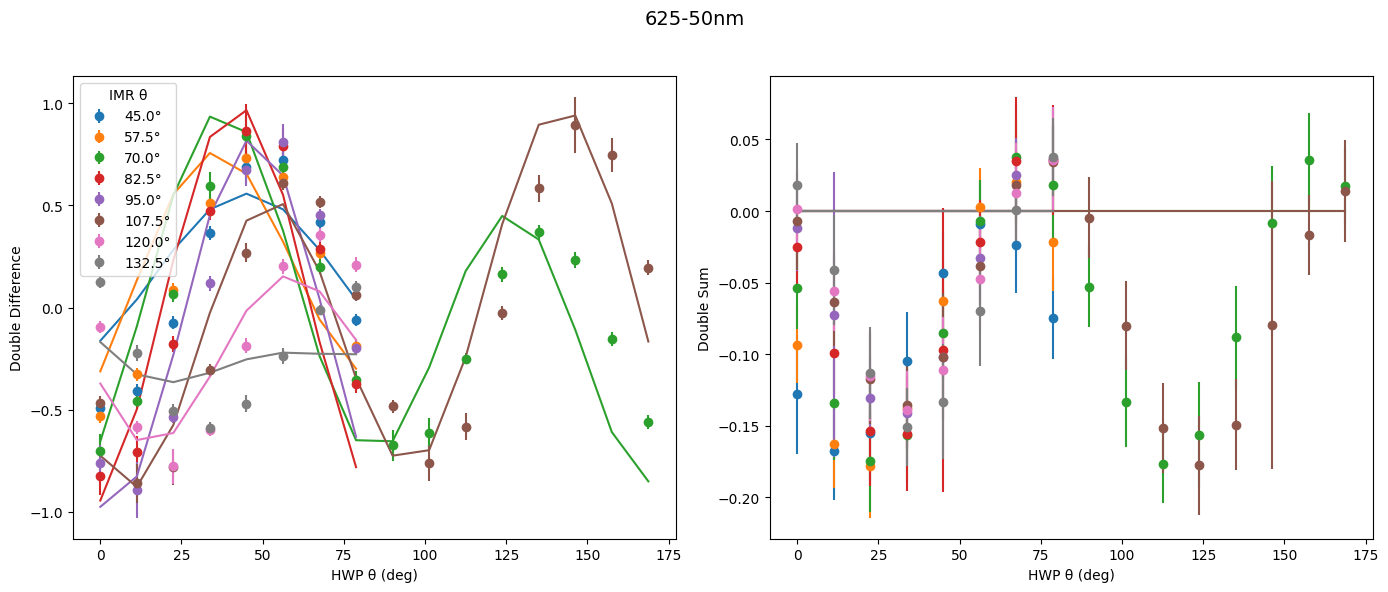

In [5]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)
p0.setdefault("image_rotator", {}).pop("delta_theta", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting initial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)


# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 1.4074335088082273}, 'hwp': {'phi': 2.714336052701581, 'delta_theta': 0}, 'lp': {'theta': 0}}


Iteration #: 1
logl_value: 418.2098217514549
Best Fit Parameters: [-2.91382767  0.06204936  4.15601935  3.29980429  4.99735336  0.39720623
  0.         -5.14934992  1.34731141  2.78614521 -4.77819885  4.99722643]


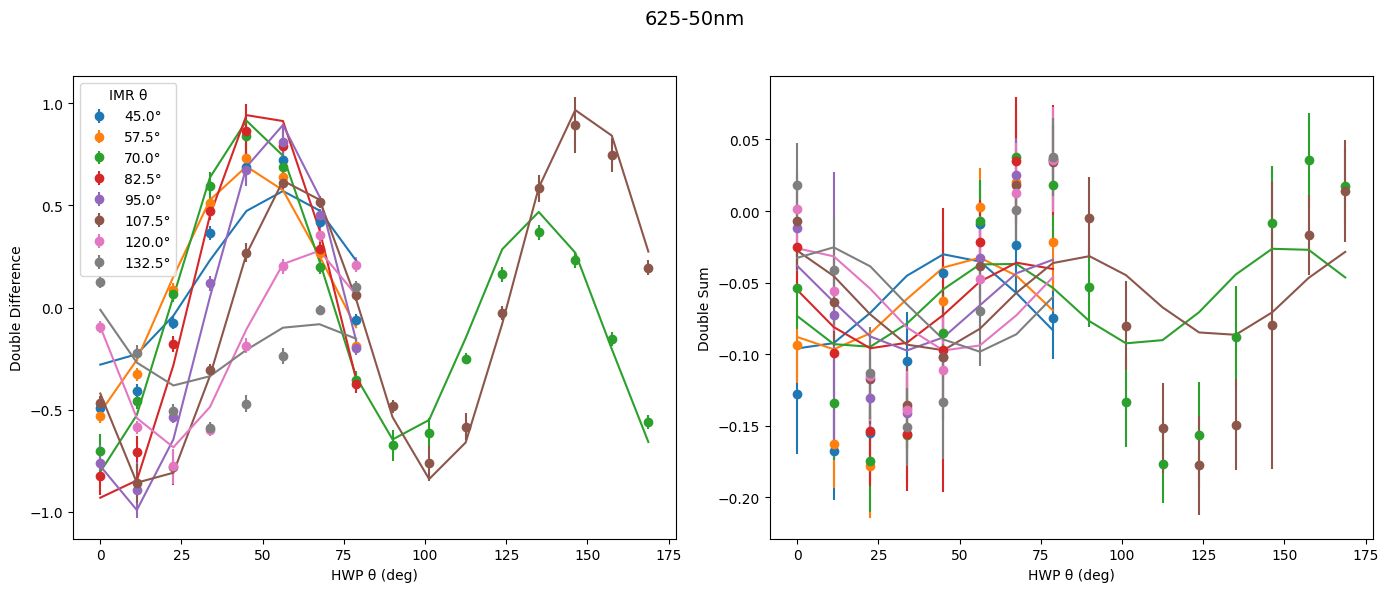

After p0: {'dichroic': {'phi': -2.9138276707446913, 'epsilon': 0.06204935564499384, 'theta': 4.156019348826021}, 'flc': {'phi': 3.299804289323319, 'delta_theta': 4.997353363739638}, 'optics': {'phi': 0.3972062288978009, 'epsilon': 0.0, 'theta': -5.149349921047008}, 'image_rotator': {'phi': 1.347311409326032}, 'hwp': {'phi': 2.7861452093593986, 'delta_theta': -4.77819884691797}, 'lp': {'theta': 4.9972264336912176}}
Before p0: {'dichroic': {'phi': -2.9138276707446913, 'epsilon': 0.06204935564499384, 'theta': 4.156019348826021}, 'flc': {'phi': 3.299804289323319, 'delta_theta': 4.997353363739638}, 'optics': {'phi': 0.3972062288978009, 'epsilon': 0.0, 'theta': -5.149349921047008}, 'image_rotator': {'phi': 1.347311409326032}, 'hwp': {'phi': 2.7861452093593986, 'delta_theta': -4.77819884691797}, 'lp': {'theta': 4.9972264336912176}}
Iteration #: 2
logl_value: 26.91961891541071
Best Fit Parameters: [-5.34034150e+00  7.69343161e-02  1.29596283e+01  2.60158327e+00
  4.99432738e+00  2.28099497e-01

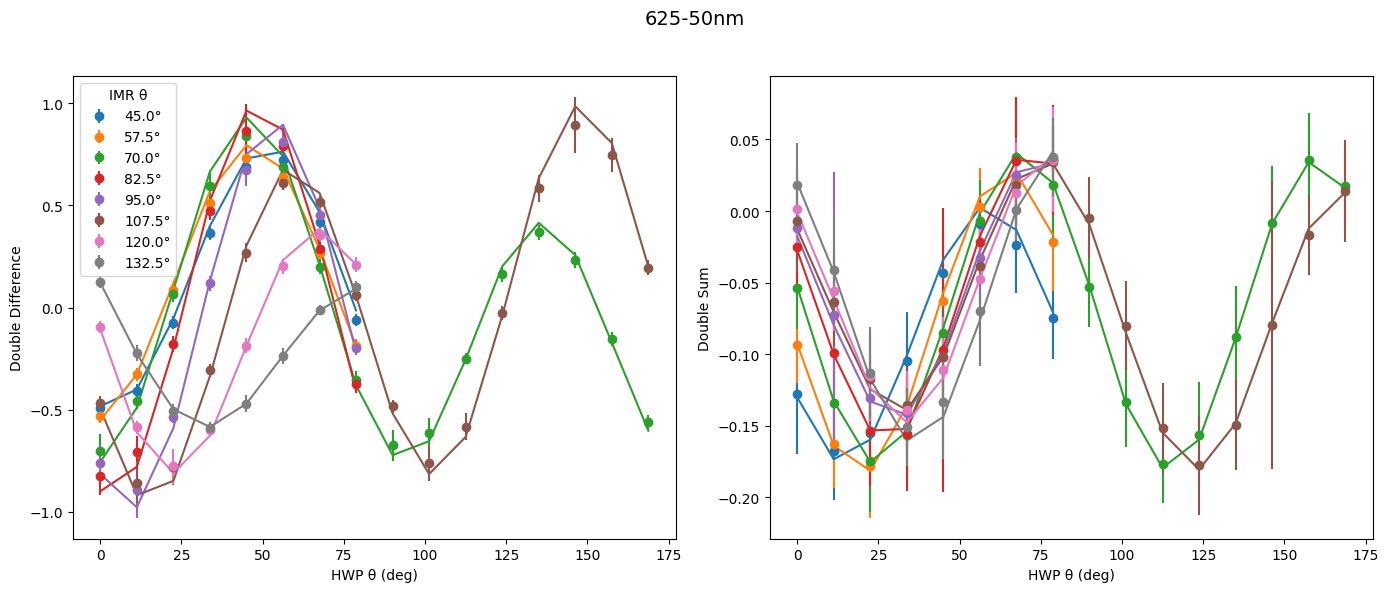

After p0: {'dichroic': {'phi': -5.340341500535782, 'epsilon': 0.07693431609615475, 'theta': 12.959628338147745}, 'flc': {'phi': 2.6015832717469785, 'delta_theta': 4.994327376766449}, 'optics': {'phi': 0.22809949669918383, 'epsilon': 0.005512177426414123, 'theta': 0.15669337245507187}, 'image_rotator': {'phi': 1.3601764817391806}, 'hwp': {'phi': 2.7502567970001266, 'delta_theta': -1.7576627121846817}, 'lp': {'theta': 0.12140226842709712}}
Before p0: {'dichroic': {'phi': -5.340341500535782, 'epsilon': 0.07693431609615475, 'theta': 12.959628338147745}, 'flc': {'phi': 2.6015832717469785, 'delta_theta': 4.994327376766449}, 'optics': {'phi': 0.22809949669918383, 'epsilon': 0.005512177426414123, 'theta': 0.15669337245507187}, 'image_rotator': {'phi': 1.3601764817391806}, 'hwp': {'phi': 2.7502567970001266, 'delta_theta': -1.7576627121846817}, 'lp': {'theta': 0.12140226842709712}}
Iteration #: 3
logl_value: 24.04441868723949
Best Fit Parameters: [-5.81907809e+00  1.28523400e-01  2.85283813e+01 

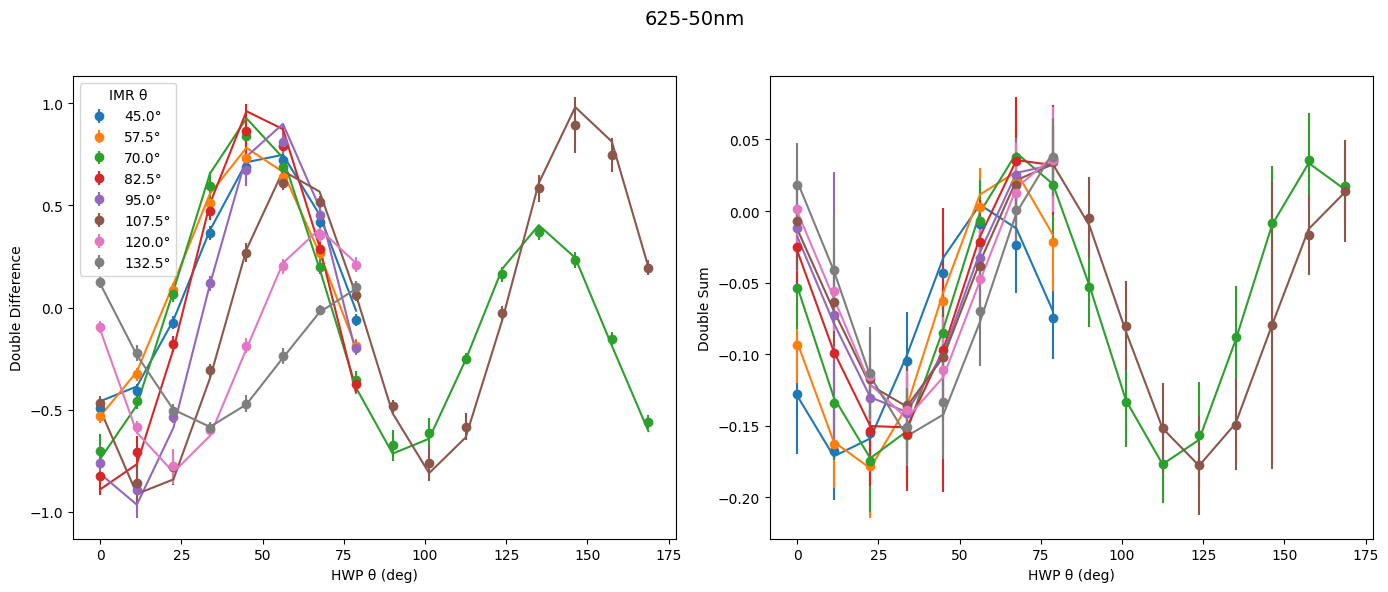

After p0: {'dichroic': {'phi': -5.819078086309034, 'epsilon': 0.12852339978516958, 'theta': 28.52838125742104}, 'flc': {'phi': 2.580629006868831, 'delta_theta': 3.5727144707620226}, 'optics': {'phi': 0.32524171920487666, 'epsilon': 0.018633546474221094, 'theta': 1.954213371505909}, 'image_rotator': {'phi': 1.3746124687218844}, 'hwp': {'phi': 2.756496273339378, 'delta_theta': -2.4780212730406728}, 'lp': {'theta': -0.9637247319715367}}
Before p0: {'dichroic': {'phi': -5.819078086309034, 'epsilon': 0.12852339978516958, 'theta': 28.52838125742104}, 'flc': {'phi': 2.580629006868831, 'delta_theta': 3.5727144707620226}, 'optics': {'phi': 0.32524171920487666, 'epsilon': 0.018633546474221094, 'theta': 1.954213371505909}, 'image_rotator': {'phi': 1.3746124687218844}, 'hwp': {'phi': 2.756496273339378, 'delta_theta': -2.4780212730406728}, 'lp': {'theta': -0.9637247319715367}}
Iteration #: 4
logl_value: 10.20167119915757
Best Fit Parameters: [-5.84730492e+00  3.70478681e-01  3.93347822e+01  2.51399

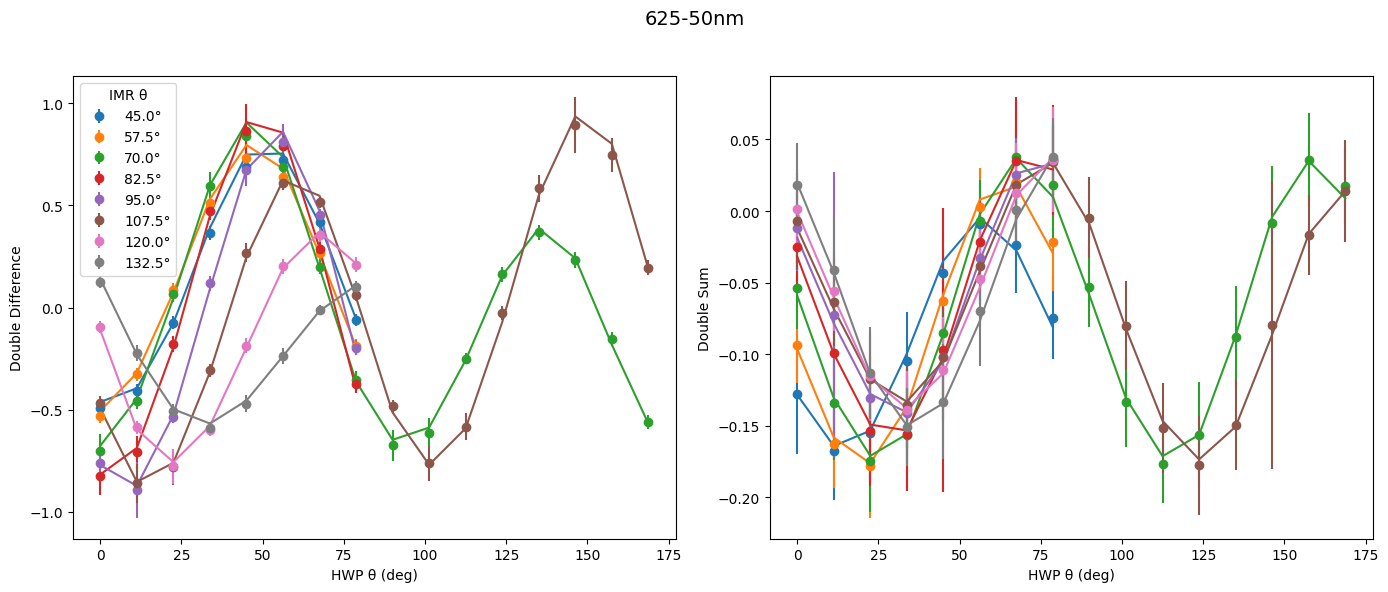

After p0: {'dichroic': {'phi': -5.847304922177292, 'epsilon': 0.3704786809446634, 'theta': 39.33478224013015}, 'flc': {'phi': 2.5139996775221483, 'delta_theta': 4.796362005483836}, 'optics': {'phi': 0.5996652894721974, 'epsilon': 0.03007773243052244, 'theta': 4.201361752961494}, 'image_rotator': {'phi': 1.3703257300522815}, 'hwp': {'phi': 2.7447309177675305, 'delta_theta': -0.651620723855661}, 'lp': {'theta': 1.21974401814286}}
Before p0: {'dichroic': {'phi': -5.847304922177292, 'epsilon': 0.3704786809446634, 'theta': 39.33478224013015}, 'flc': {'phi': 2.5139996775221483, 'delta_theta': 4.796362005483836}, 'optics': {'phi': 0.5996652894721974, 'epsilon': 0.03007773243052244, 'theta': 4.201361752961494}, 'image_rotator': {'phi': 1.3703257300522815}, 'hwp': {'phi': 2.7447309177675305, 'delta_theta': -0.651620723855661}, 'lp': {'theta': 1.21974401814286}}
Iteration #: 5
logl_value: 9.947062574579288
Best Fit Parameters: [-5.86361610e+00  3.75547430e-01  3.93376635e+01  2.56160768e+00
  3.

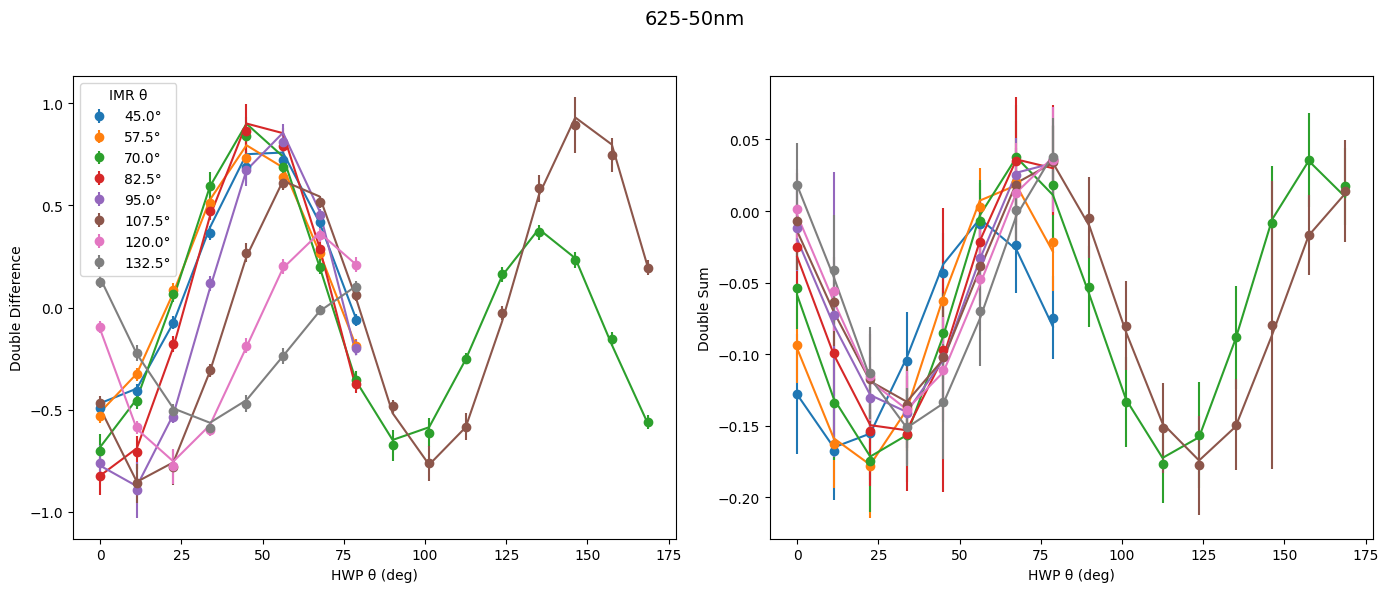

After p0: {'dichroic': {'phi': -5.8636160983368395, 'epsilon': 0.3755474300769447, 'theta': 39.33766349540289}, 'flc': {'phi': 2.5616076839543096, 'delta_theta': 3.857416219333598}, 'optics': {'phi': 0.37803728334895503, 'epsilon': 0.02829909637057096, 'theta': -0.4242303685682482}, 'image_rotator': {'phi': 1.3663394248966019}, 'hwp': {'phi': 2.7409938445210322, 'delta_theta': -0.2461622352936207}, 'lp': {'theta': 1.9261613211051936}}
Before p0: {'dichroic': {'phi': -5.8636160983368395, 'epsilon': 0.3755474300769447, 'theta': 39.33766349540289}, 'flc': {'phi': 2.5616076839543096, 'delta_theta': 3.857416219333598}, 'optics': {'phi': 0.37803728334895503, 'epsilon': 0.02829909637057096, 'theta': -0.4242303685682482}, 'image_rotator': {'phi': 1.3663394248966019}, 'hwp': {'phi': 2.7409938445210322, 'delta_theta': -0.2461622352936207}, 'lp': {'theta': 1.9261613211051936}}
Iteration #: 6
logl_value: 8.35646835805143
Best Fit Parameters: [-5.89934009e+00  3.81063179e-01  3.94545892e+01  2.6423

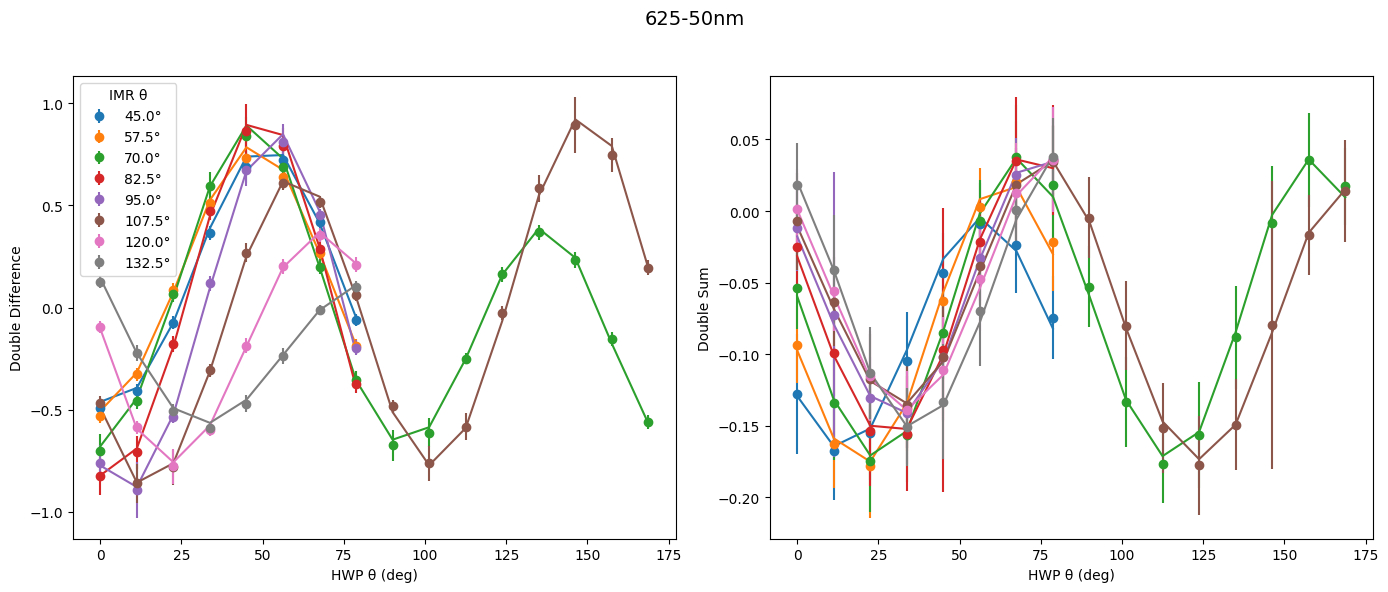

After p0: {'dichroic': {'phi': -5.899340088290074, 'epsilon': 0.3810631793104917, 'theta': 39.454589150217075}, 'flc': {'phi': 2.6423191203453764, 'delta_theta': 3.0629405634292053}, 'optics': {'phi': 0.18717801843951207, 'epsilon': 0.032731163863405424, 'theta': -14.795265738719856}, 'image_rotator': {'phi': 1.3690871455629288}, 'hwp': {'phi': 2.744734730967592, 'delta_theta': -0.4920210315793424}, 'lp': {'theta': 1.561190960960229}}
Before p0: {'dichroic': {'phi': -5.899340088290074, 'epsilon': 0.3810631793104917, 'theta': 39.454589150217075}, 'flc': {'phi': 2.6423191203453764, 'delta_theta': 3.0629405634292053}, 'optics': {'phi': 0.18717801843951207, 'epsilon': 0.032731163863405424, 'theta': -14.795265738719856}, 'image_rotator': {'phi': 1.3690871455629288}, 'hwp': {'phi': 2.744734730967592, 'delta_theta': -0.4920210315793424}, 'lp': {'theta': 1.561190960960229}}
Iteration #: 7
logl_value: 7.70743155390894
Best Fit Parameters: [ -5.90461749   0.37810493  39.30854532   2.65586399   2

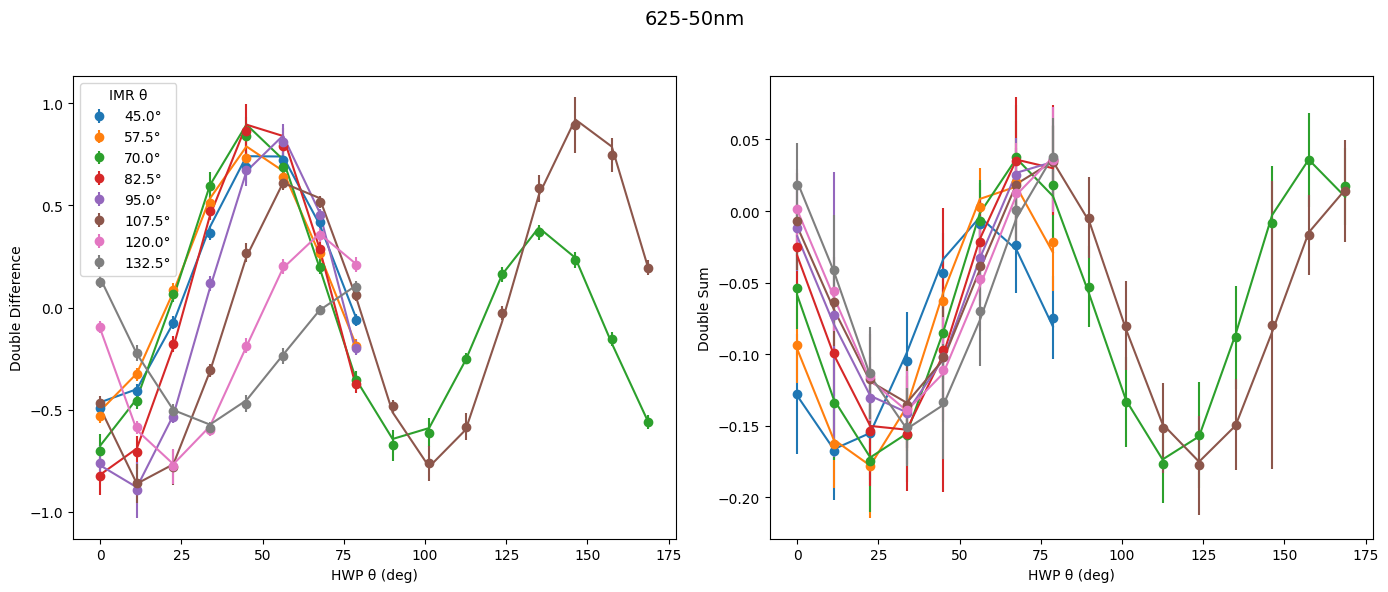

After p0: {'dichroic': {'phi': -5.904617492519497, 'epsilon': 0.378104932710541, 'theta': 39.308545318159645}, 'flc': {'phi': 2.6558639865087166, 'delta_theta': 2.878676471461838}, 'optics': {'phi': 0.15494422979851497, 'epsilon': 0.048798393931005796, 'theta': -22.923613457776824}, 'image_rotator': {'phi': 1.3687405246402564}, 'hwp': {'phi': 2.7444124959518756, 'delta_theta': -0.5138758894541031}, 'lp': {'theta': 1.5050208318296256}}
Before p0: {'dichroic': {'phi': -5.904617492519497, 'epsilon': 0.378104932710541, 'theta': 39.308545318159645}, 'flc': {'phi': 2.6558639865087166, 'delta_theta': 2.878676471461838}, 'optics': {'phi': 0.15494422979851497, 'epsilon': 0.048798393931005796, 'theta': -22.923613457776824}, 'image_rotator': {'phi': 1.3687405246402564}, 'hwp': {'phi': 2.7444124959518756, 'delta_theta': -0.5138758894541031}, 'lp': {'theta': 1.5050208318296256}}
Iteration #: 8
logl_value: 7.707431551687023
Best Fit Parameters: [ -5.90461748   0.37810609  39.30856642   2.65586438   

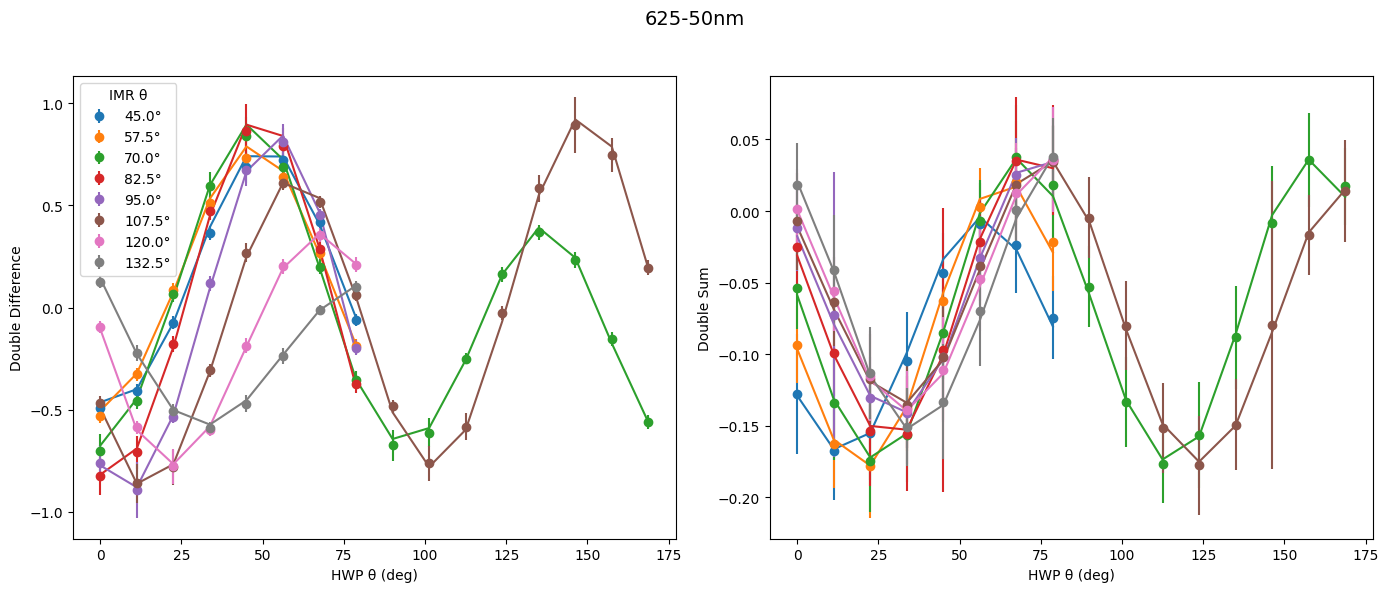

After p0: {'dichroic': {'phi': -5.904617480260078, 'epsilon': 0.37810608754422126, 'theta': 39.308566421329935}, 'flc': {'phi': 2.6558643790008962, 'delta_theta': 2.878680604841537}, 'optics': {'phi': 0.15494497646361874, 'epsilon': 0.04879845608650446, 'theta': -22.92356612089747}, 'image_rotator': {'phi': 1.3687403331605223}, 'hwp': {'phi': 2.7444127136054184, 'delta_theta': -0.5138824909297903}, 'lp': {'theta': 1.505000852049387}}
Before p0: {'dichroic': {'phi': -5.904617480260078, 'epsilon': 0.37810608754422126, 'theta': 39.308566421329935}, 'flc': {'phi': 2.6558643790008962, 'delta_theta': 2.878680604841537}, 'optics': {'phi': 0.15494497646361874, 'epsilon': 0.04879845608650446, 'theta': -22.92356612089747}, 'image_rotator': {'phi': 1.3687403331605223}, 'hwp': {'phi': 2.7444127136054184, 'delta_theta': -0.5138824909297903}, 'lp': {'theta': 1.505000852049387}}
Iteration #: 9
logl_value: 7.7074315513215375
Best Fit Parameters: [ -5.90461731   0.37810636  39.30857049   2.65586406   2

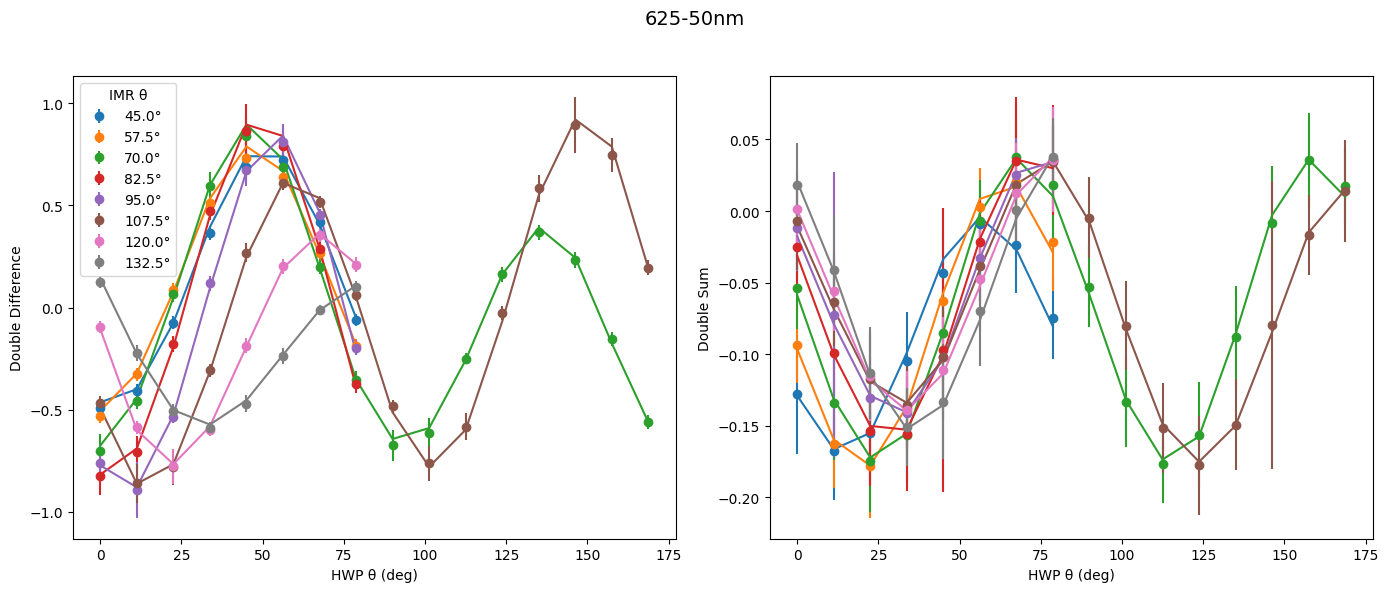

After p0: {'dichroic': {'phi': -5.904617309777988, 'epsilon': 0.37810636269383424, 'theta': 39.308570492206954}, 'flc': {'phi': 2.6558640627311605, 'delta_theta': 2.8786811819105966}, 'optics': {'phi': 0.15494506335845065, 'epsilon': 0.04879835029642471, 'theta': -22.923536423800826}, 'image_rotator': {'phi': 1.3687405467858564}, 'hwp': {'phi': 2.744412747361121, 'delta_theta': -0.5138693049372367}, 'lp': {'theta': 1.5050267579222374}}
Before p0: {'dichroic': {'phi': -5.904617309777988, 'epsilon': 0.37810636269383424, 'theta': 39.308570492206954}, 'flc': {'phi': 2.6558640627311605, 'delta_theta': 2.8786811819105966}, 'optics': {'phi': 0.15494506335845065, 'epsilon': 0.04879835029642471, 'theta': -22.923536423800826}, 'image_rotator': {'phi': 1.3687405467858564}, 'hwp': {'phi': 2.744412747361121, 'delta_theta': -0.5138693049372367}, 'lp': {'theta': 1.5050267579222374}}
Iteration #: 10
logl_value: 7.707431551227415
Best Fit Parameters: [ -5.90461723   0.37810648  39.30857549   2.65586403

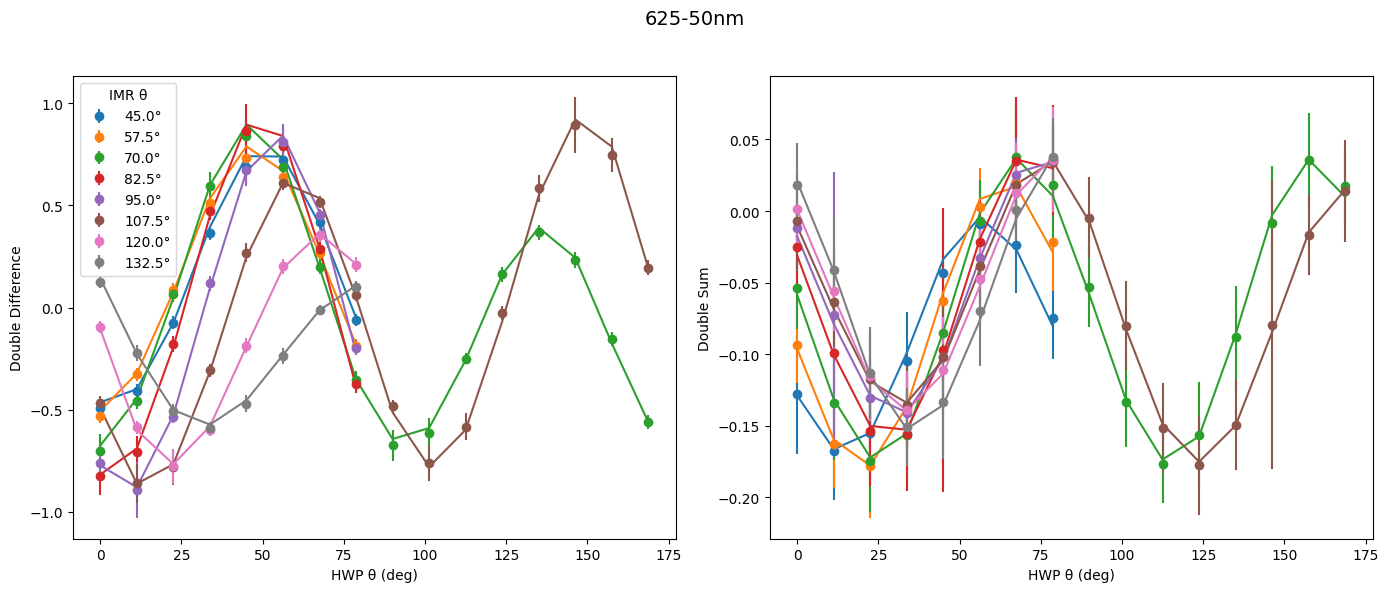

After p0: {'dichroic': {'phi': -5.904617233748835, 'epsilon': 0.3781064773476369, 'theta': 39.30857548856574}, 'flc': {'phi': 2.6558640325174916, 'delta_theta': 2.8786805807768086}, 'optics': {'phi': 0.15494485122109558, 'epsilon': 0.04879839344026632, 'theta': -22.923524016313117}, 'image_rotator': {'phi': 1.3687404442768685}, 'hwp': {'phi': 2.7444127272784744, 'delta_theta': -0.5138854522457383}, 'lp': {'theta': 1.5049997355238833}}
Before p0: {'dichroic': {'phi': -5.904617233748835, 'epsilon': 0.3781064773476369, 'theta': 39.30857548856574}, 'flc': {'phi': 2.6558640325174916, 'delta_theta': 2.8786805807768086}, 'optics': {'phi': 0.15494485122109558, 'epsilon': 0.04879839344026632, 'theta': -22.923524016313117}, 'image_rotator': {'phi': 1.3687404442768685}, 'hwp': {'phi': 2.7444127272784744, 'delta_theta': -0.5138854522457383}, 'lp': {'theta': 1.5049997355238833}}
Iteration #: 11
logl_value: 7.707431551057203
Best Fit Parameters: [ -5.90461717   0.37810637  39.30857215   2.65586395  

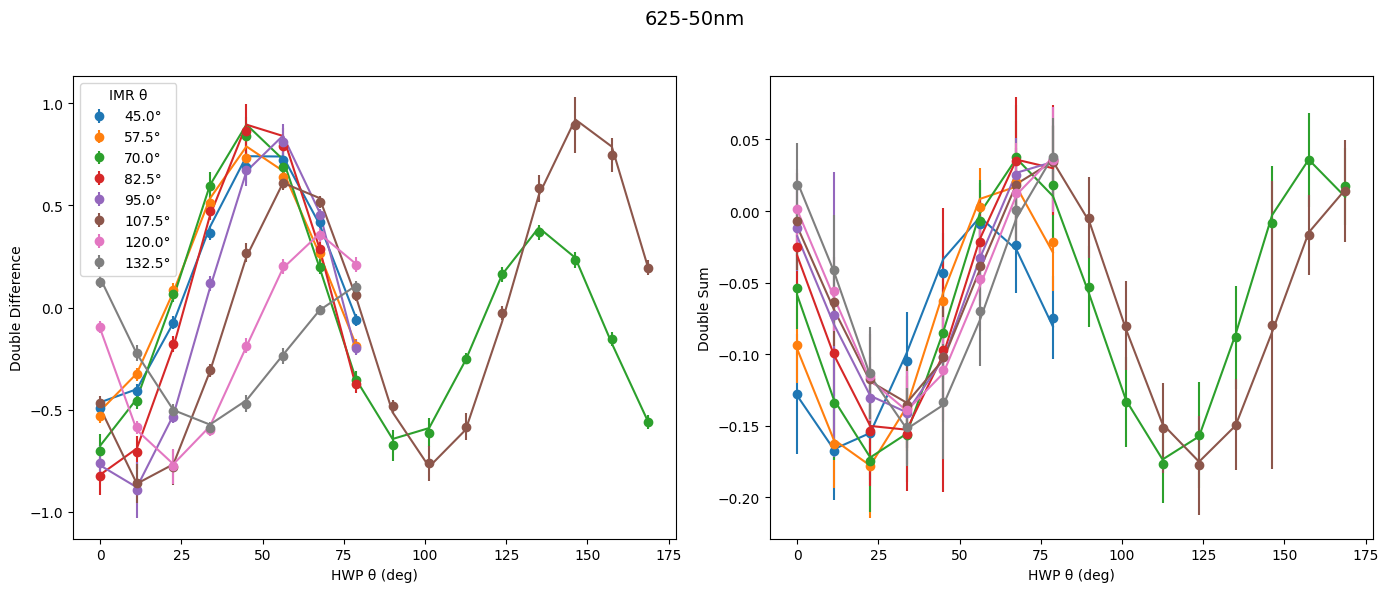

After p0: {'dichroic': {'phi': -5.904617171852047, 'epsilon': 0.3781063653634011, 'theta': 39.30857214800309}, 'flc': {'phi': 2.6558639477561448, 'delta_theta': 2.87867981016701}, 'optics': {'phi': 0.15494479410897816, 'epsilon': 0.04879842328817753, 'theta': -22.92353979381876}, 'image_rotator': {'phi': 1.3687404686170406}, 'hwp': {'phi': 2.7444127031922365, 'delta_theta': -0.5138825593513623}, 'lp': {'theta': 1.5050052133329594}}
Before p0: {'dichroic': {'phi': -5.904617171852047, 'epsilon': 0.3781063653634011, 'theta': 39.30857214800309}, 'flc': {'phi': 2.6558639477561448, 'delta_theta': 2.87867981016701}, 'optics': {'phi': 0.15494479410897816, 'epsilon': 0.04879842328817753, 'theta': -22.92353979381876}, 'image_rotator': {'phi': 1.3687404686170406}, 'hwp': {'phi': 2.7444127031922365, 'delta_theta': -0.5138825593513623}, 'lp': {'theta': 1.5050052133329594}}
Iteration #: 12
logl_value: 7.707431551057203
Best Fit Parameters: [ -5.90461717   0.37810637  39.30857215   2.65586395   2.878

In [6]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-2 * np.pi, 2 * np.pi),  # delta_opts
    (0, 1),  # epsilon_opts
    (-90, 90),  # rot_opts
    (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),  # delta_derot
    (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values_EM_gain_1.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

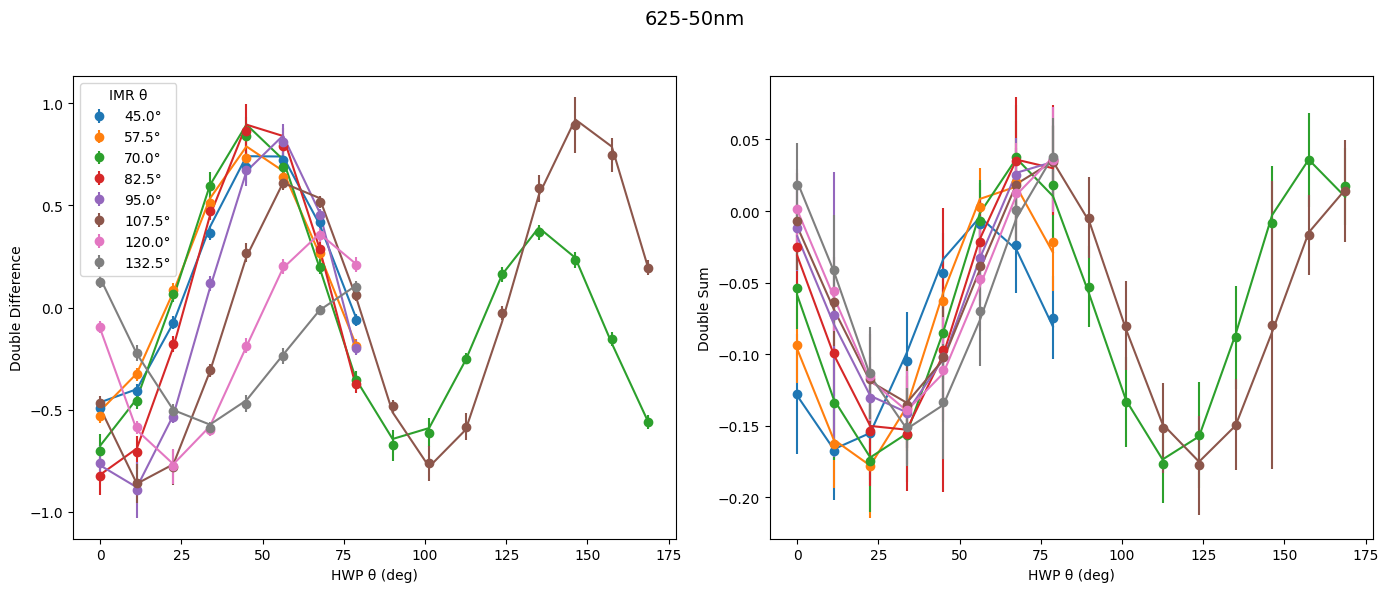

In [7]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
# dichroic_phi = 0 # (waves)
# dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)